# Weight Initialization

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch_dataset
import copy


In [2]:
def gaussian(x, sigma):
    '''
     y = gaussian(x, sigma)
     Evaluates the Gaussian function with standard deviation sigma.
    '''
    c = np.sqrt(2 * np.pi)
    return np.exp(-0.5 * (x / sigma)**2) / sigma / c

# Distribution of inputs

In [ ]:
M = 500    # Number of input neurons
P = 50000  # Number of input samples

# Generate input samples from N(0,1) (standard deviation = 1)
x = np.random.normal(size=(P,M), scale=1.)

In [4]:
# Check that the mean is close to zero.
np.mean(x)

np.float64(0.00040074804732427)

In [5]:
# Check that the variance is close to 1.
np.var(x) 

np.float64(0.999733455592902)

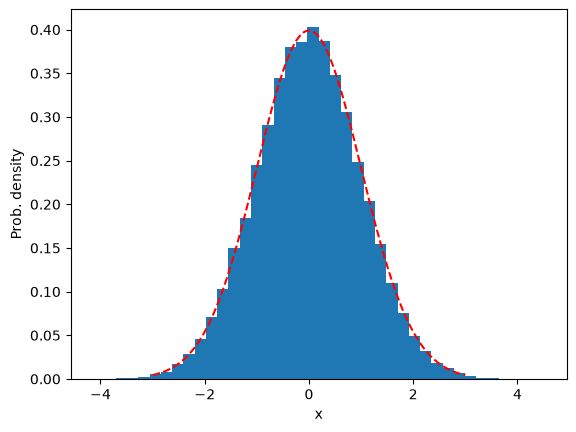

In [6]:
# Plot the histrogram as a density function, along with
# the p.d.f. for N(0,1).

m = np.random.randint(M)  # Randomly choose an input neuron

# Plot histogram
v = plt.hist(x[:,m], bins=40, density=True);
plt.xlabel('x')
plt.ylabel('Prob. density')

# Plot p.d.f. of N(0,1)
xx = np.linspace(-3, 3, 300);
yy = gaussian(xx, 1.)
plt.plot(xx, yy, 'r--');

# Generate random weights

In [8]:
# Randomly generate the connection-weight matrix, W.

W = np.random.normal(size = (M, M), scale = np.sqrt(4 / (225 * M)))


# Plot distribution of $h$

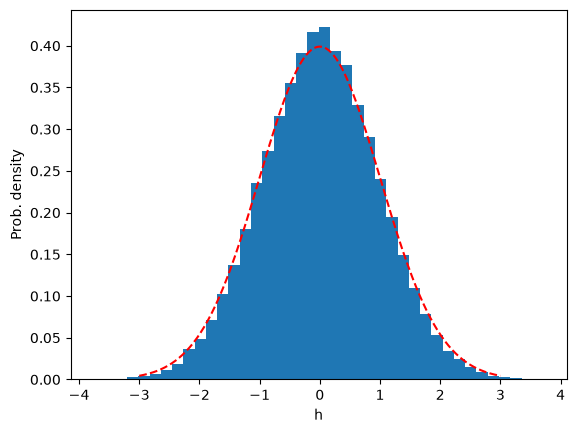

In [9]:
h = 15 * np.arctan(0.5 * (x @ W))

# Plot histogram and p.d.f. of N(0,1)
m = np.random.randint(M)

v = plt.hist(h[:,m], bins=40, density=True);
plt.xlabel('h')
plt.ylabel('Prob. density')

xx = np.linspace(-3, 3, 300);
yy = gaussian(xx, 1.)
plt.plot(xx, yy, 'r--');


# Print mean and variance

In [10]:
# Mean
print('Mean = ', np.mean(h))


Mean =  -0.0002093427284711595


In [11]:
# Variance
print('Variance =', np.var(h))


Variance = 0.9886792857631831


# Implementing SGD and Momentum

In [12]:
# Dataset
ds = torch_dataset.Annuli(n=1000)

In [13]:
ds.classes()[:10]

tensor([0, 1, 2, 1, 1, 2, 2, 1, 2, 2], dtype=torch.int32)

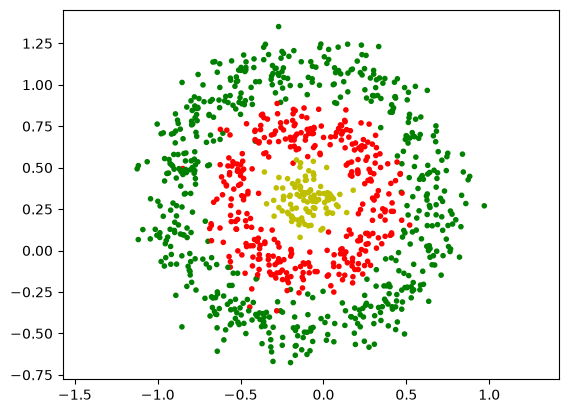

In [14]:
ds.plot()

In [15]:
dl = torch.utils.data.DataLoader(ds, batch_size=70, shuffle=True)
for x,t in dl:
    print(f'x has {len(x)} samples, t has {len(t)} samples')

x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 70 samples, t has 70 samples
x has 20 samples, t has 20 samples


In [16]:
# Implement SGD with momentum

def sgd(net, dl, loss_func, lrate=0.1, epochs=10, momentum=0.):
    '''
     losses = sgd(net, dl, loss_func, lrate=0.1, epochs=10, momentum=0.)

     Performs learning using stochastic gradient descent (SGD).

     Inputs:
       net        PyTorch nn.Module
       dl         PyTorch DataLoader object
       loss_func  PyTorch loss function
       lrate      learning rate
       epochs     number of epochs to run (max)
                  It stops early if the loss goes below 0.1.
       momentum   momentum parameter, from the range [0, 1)

     Output:
       losses     list of the loss at the end of each epoch
    '''
    losses = []
    velocities = []

    for p in net.parameters():
      velocities.append(torch.zeros_like(p))

    for epoch in range(epochs):
        epoch += 1
        total_loss = 0.0
        total_samples = 0

        for x, t in dl:

          net.zero_grad()

          outputs = net(x)
          loss = loss_func(outputs, t)

          loss.backward()

          batch_size = x.size(0)

          with torch.no_grad():
            for i, p in enumerate(net.parameters()):
              velocities[i] = momentum * velocities[i] + p.grad
              p -= lrate * velocities[i]

          total_loss += (loss.item() * batch_size)
          total_samples += batch_size


        avg_loss = total_loss / total_samples

        if avg_loss < 0.1:
          break

        losses.append(avg_loss)
    return losses

In [17]:
# SGD, one batch, no momentum
net_orig = nn.Sequential(
        nn.Linear(2,16),
        nn.Tanh(),
        nn.Linear(16, 16),
        nn.Tanh(),
        nn.Linear(16, 3)
)

lr = 0.05   # choose a learning rate

In [18]:
net = copy.deepcopy(net_orig)

ds = torch_dataset.Annuli(n=300, noise=1.0)
dl = torch.utils.data.DataLoader(ds, batch_size=len(ds), shuffle=True)

loss_func = nn.CrossEntropyLoss()
losses1 = sgd(net, dl, loss_func, lrate=lr, epochs=3000, momentum=0.0)

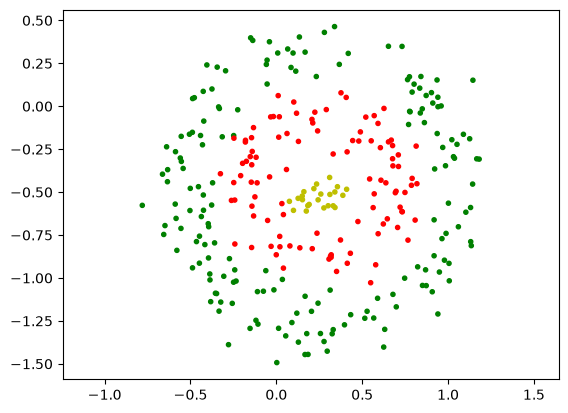

In [19]:
ds.plot(labels=net(ds.inputs()))

In [20]:
# SGD, with mini-batches, with and without momentum

# SGD with mini-batches, no momentum
net2 = copy.deepcopy(net_orig)

dl_mini = torch.utils.data.DataLoader(ds, batch_size=100, shuffle=True)

losses2 = sgd(net2, dl_mini, loss_func, lrate=lr, epochs=3000, momentum=0.0)

In [21]:
# SGD with momentum, but no mini-batches
net3 = copy.deepcopy(net_orig)

losses3 = sgd(net3, dl, loss_func, lrate=lr, epochs=3000, momentum=0.9)

In [22]:
# SGD with momentum and mini-batches
net4 = copy.deepcopy(net_orig)

losses4 = sgd(net4, dl_mini, loss_func, lrate=lr, epochs=3000, momentum=0.9)


# Plot learning curves

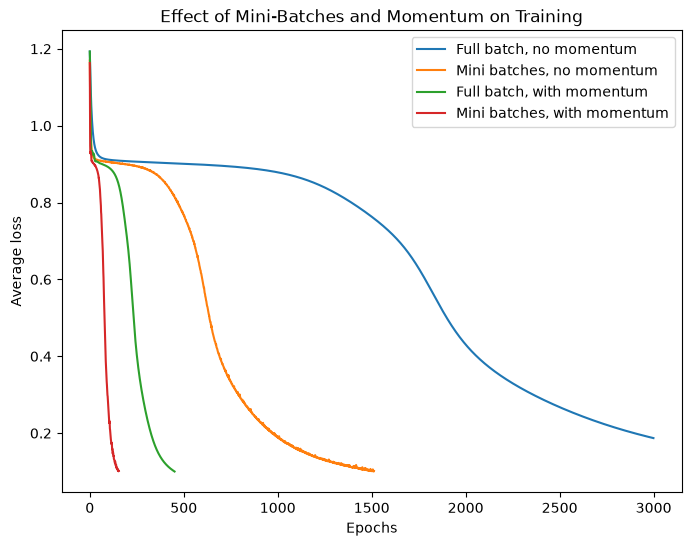

In [23]:
plt.figure(figsize=(8,6))
plt.plot(losses1, label='Full batch, no momentum')
plt.plot(losses2, label='Mini batches, no momentum')
plt.plot(losses3, label='Full batch, with momentum')
plt.plot(losses4, label='Mini batches, with momentum')

plt.title('Effect of Mini-Batches and Momentum on Training')
plt.xlabel('Epochs')
plt.ylabel('Average loss')
plt.legend()
plt.show()